# Monte Carlo Kernel Benchmarking

This notebook performs a comprehensive performance evaluation of different OpenCL kernels implemented for the Monte Carlo simulation. We compare the **Standard 1D**, **Ping-Pong**, and the **Vectorized** approaches across various metrics, including execution time, memory bandwidth, VRAM footprint, and throughput.

**Bandwidth metric.** The reported *Effective Bandwidth* is computed as `(n_runs × n_cells × 4 + n_wg × 4) / time` (canonical effective-bandwidth convention: every global-memory load/store instruction is counted at face value, regardless of cache hits). Because `p_vec` (~600 KB for this habitat) fits in the GPU's L2 cache, the measured values can exceed the device's DRAM peak (the 4050 is ~190-270 GB/s) — in that regime the metric reflects cache→SM throughput, not VRAM→SM.

## Environment Setup

Loading environment variables and importing necessary modules for the simulation and data analysis.

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

from pyroclast import (
    FileMapRepository,
    HabitatCriteria,
    PyOpenCLAdapter,
    PyOpenCLMonteCarloAdapter,
    PyOpenCLMonteCarloPingPongAdapter,
    PyOpenCLMonteCarloVectorizedAdapter,
    PyOpenCLMonteCarloVectorizedPingPongAdapter,
)
from pyroclast.domain.models import GridTopology, MonteCarloConfig
from pyroclast.services import run_preprocessing_batch

load_dotenv()
data_path = os.getenv("DATA_PATH", "data").strip('"\'')
cache_dir = Path(os.getenv("CACHE_DIR", str(Path(data_path) / "cache")).strip('"\''))

## Data Preparation

Running the preprocessing pipeline to obtain the compacted habitat data required for the Monte Carlo simulation.

In [3]:
repo = FileMapRepository(data_path)
preprocess_adapter = PyOpenCLAdapter()
compacted = run_preprocessing_batch(
    repo=repo,
    compute=preprocess_adapter,
    criteria=HabitatCriteria(),
    cache_dir=cache_dir,
)
target_habitat = compacted[0]
print(f"Selected Habitat: {target_habitat.habitat_code} ({target_habitat.n_cells} cells)")

Selected Habitat: 4090 (153989 cells)


pci id for fd 86: 10de:28e1, driver (null)
pci id for fd 88: 10de:28e1, driver (null)


## Phase 1: Single-Shot Performance Analysis

Executing a single benchmark run with a high number of simulations (1,000,000) for all kernels to collect detailed performance metrics including VRAM footprint and speedup.

In [4]:
MC_RUNS = 1_000_000
THRESHOLD = 0.005
SEED = 42
N_BATCHES = 10

kernels_to_bench = [
    {"name": "Standard",       "adapter": PyOpenCLMonteCarloAdapter(profiling=True)},
    {"name": "Ping-Pong",      "adapter": PyOpenCLMonteCarloPingPongAdapter(profiling=True)},
    {"name": "Vec-w2",        "adapter": PyOpenCLMonteCarloVectorizedAdapter(profiling=True, vec_width=2)},
    {"name": "VecPP-w2",      "adapter": PyOpenCLMonteCarloVectorizedPingPongAdapter(profiling=True, vec_width=2)},
]


def _canonical_topology(adapter, n_wg_target: int) -> GridTopology:
    return GridTopology(gws=n_wg_target * 256, lws=256)


max_cu = kernels_to_bench[0]["adapter"]._ctx.devices[0].max_compute_units
n_wg_target = max_cu * 8
print(f"Canonical n_wg = {n_wg_target}  (max_cu={max_cu} × 8)")

phase1_data = []

print(f"Running Phase 1 Benchmark (R={MC_RUNS:,}, Batches={N_BATCHES})...")
for k in kernels_to_bench:
    adapter = k["adapter"]
    cfg = MonteCarloConfig(
        n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED,
        topology=_canonical_topology(adapter, n_wg_target),
    )
    adapter.reset_profile()
    adapter.run(target_habitat, cfg)
    bench = adapter.benchmark()[0]

    total_time_ms = bench.mean_ms * N_BATCHES
    throughput = MC_RUNS / (total_time_ms / 1000.0)

    phase1_data.append({
        "Kernel": k["name"],
        "Topology": f"{cfg.topology.gws} / {cfg.topology.lws}",
        "Time (ms)": total_time_ms,
        "Bandwidth (GB/s)": bench.bandwidth_gbs,
        "VRAM (MB)": bench.memory_mb,
        "Throughput (Sim/s)": throughput
    })

df_phase1 = pd.DataFrame(phase1_data)
std_time = df_phase1[df_phase1["Kernel"] == "Standard"]["Time (ms)"].values[0]
df_phase1["Speedup"] = std_time / df_phase1["Time (ms)"]

print("\nPhase 1 Results (n_wg canonical = same for all kernels):")
display(df_phase1.style.format({
    "Time (ms)": "{:.2f}",
    "Bandwidth (GB/s)": "{:.1f}",
    "VRAM (MB)": "{:.2f}",
    "Throughput (Sim/s)": "{:.0f}",
    "Speedup": "{:.2f}x"
}))

Canonical n_wg = 160  (max_cu=20 × 8)
Running Phase 1 Benchmark (R=1,000,000, Batches=10)...

Phase 1 Results (n_wg canonical = same for all kernels):


,Kernel,Topology,Time (ms),Bandwidth (GB/s),VRAM (MB),Throughput (Sim/s),Speedup
0,Standard,40960 / 256,5782.54,1065.2,0.62,172934,1.00x
1,Ping-Pong,40960 / 256,5548.57,1110.1,0.62,180226,1.04x
2,Vec-w2,40960 / 256,5348.67,1151.6,0.62,186962,1.08x
3,VecPP-w2,40960 / 256,5402.25,1140.2,0.62,185108,1.07x


## Phase 2: Scaling and Throughput Analysis

Performing a parametric sweep from 1,000,000 to 2,000,000 simulations (with 100,000 increments) to observe the scalability of each kernel and how metrics like effective bandwidth and throughput behave under increasing load.

In [5]:
RUNS_MIN = 1_000_000
RUNS_MAX = 2_000_000
INCREMENT = 100_000
N_BATCHES_SCALING = 1

run_sizes = list(range(RUNS_MIN, RUNS_MAX + 1, INCREMENT))
results_scaling = {k["name"]: [] for k in kernels_to_bench}
bandwidths_scaling = {k["name"]: [] for k in kernels_to_bench}
throughputs_scaling = {k["name"]: [] for k in kernels_to_bench}

print(f"Running Phase 2 Scaling Benchmark (n_wg canonical = {n_wg_target})...")
for runs in run_sizes:
    for k in kernels_to_bench:
        adapter = k["adapter"]
        cfg = MonteCarloConfig(
            n_runs=runs, threshold=THRESHOLD, seed=SEED,
            topology=_canonical_topology(adapter, n_wg_target),
        )
        adapter.reset_profile()
        adapter.run_batched(target_habitat, cfg, N_BATCHES_SCALING)
        bench = adapter.benchmark()[0]

        total_time_ms = bench.mean_ms * N_BATCHES_SCALING
        throughput = runs / (total_time_ms / 1000.0)

        results_scaling[k["name"]].append(total_time_ms)
        bandwidths_scaling[k["name"]].append(bench.bandwidth_gbs)
        throughputs_scaling[k["name"]].append(throughput)
    print(f"  Completed R={runs:,}", end="\r")
print("\nScaling benchmark completed.")

Running Phase 2 Scaling Benchmark (n_wg canonical = 160)...
  Completed R=2,000,000
Scaling benchmark completed.


## Visualization of Results

Plotting the scaling results to compare absolute execution times, standardized deviations, effective memory bandwidth, and computational throughput.

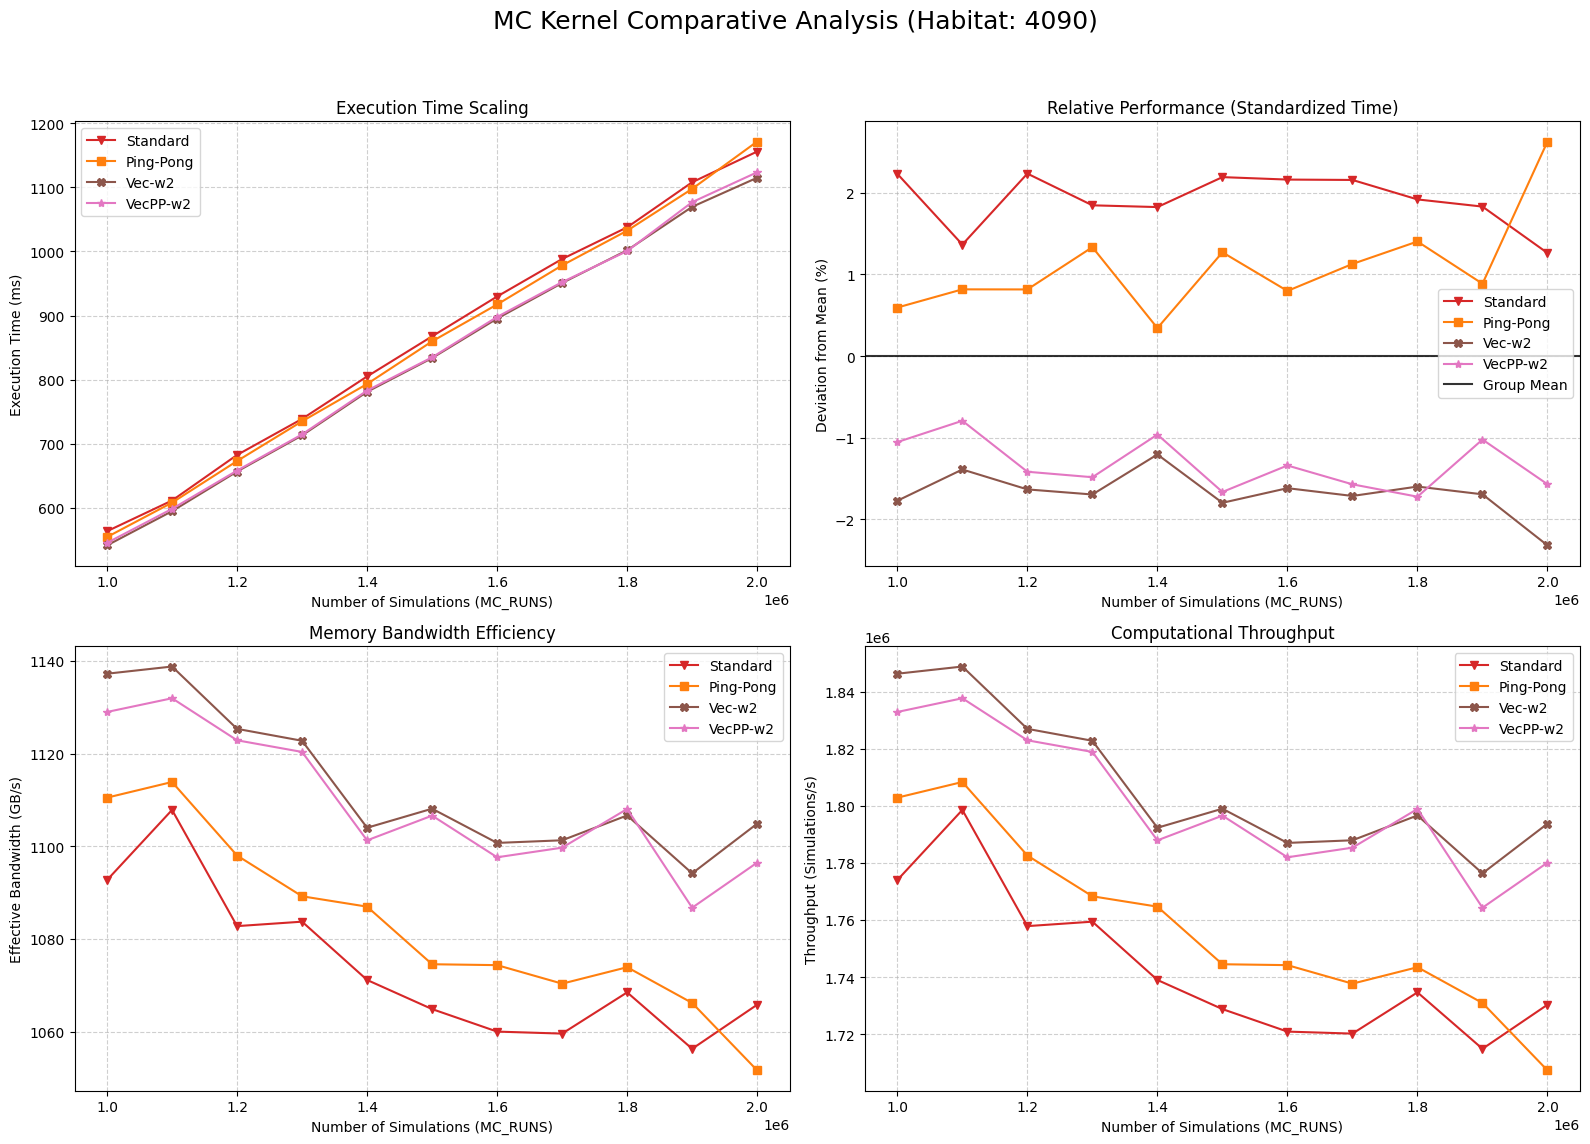

In [6]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
colors = {
    "Standard": "#d62728",
    "Ping-Pong": "#ff7f0e",
    "Vec-w2": "#8c564b",
    "VecPP-w2": "#e377c2"
}
markers = {
    "Standard": "v",
    "Ping-Pong": "s",
    "Vec-w2": "X",
    "VecPP-w2": "*"
}

# Subplot 1: Time Scaling
for k in kernels_to_bench:
    name = k["name"]
    ax1.plot(run_sizes, results_scaling[name], marker=markers[name], label=name, color=colors[name])
ax1.set_xlabel("Number of Simulations (MC_RUNS)")
ax1.set_ylabel("Execution Time (ms)")
ax1.set_title("Execution Time Scaling")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Relative Time (Deviation from Mean)
for k in kernels_to_bench:
    name = k["name"]
    # Standardized Relative Performance calculation
    deviations = []
    for i, runs in enumerate(run_sizes):
        group_mean = np.mean([results_scaling[other["name"]][i] for other in kernels_to_bench])
        val = results_scaling[name][i]
        dev_pct = (val / group_mean - 1.0) * 100.0
        deviations.append(dev_pct)
    ax2.plot(run_sizes, deviations, marker=markers[name], label=name, color=colors[name])
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Number of Simulations (MC_RUNS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

# Subplot 3: Bandwidth scaling
for k in kernels_to_bench:
    name = k["name"]
    ax3.plot(run_sizes, bandwidths_scaling[name], marker=markers[name], label=name, color=colors[name])
ax3.set_xlabel("Number of Simulations (MC_RUNS)")
ax3.set_ylabel("Effective Bandwidth (GB/s)")
ax3.set_title("Memory Bandwidth Efficiency")
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend()

# Subplot 4: Throughput
for k in kernels_to_bench:
    name = k["name"]
    ax4.plot(run_sizes, throughputs_scaling[name], marker=markers[name], label=name, color=colors[name])
ax4.set_xlabel("Number of Simulations (MC_RUNS)")
ax4.set_ylabel("Throughput (Simulations/s)")
ax4.set_title("Computational Throughput")
ax4.grid(True, linestyle="--", alpha=0.6)
ax4.legend()

plt.suptitle(f"MC Kernel Comparative Analysis (Habitat: {target_habitat.habitat_code})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Vectorization Width Sweep — "how far can we push?"

The vectorized kernel uses MWC64X's vector RNG (`mwc64xvec2/4/8`) to advance `W` independent lanes per `Step()`. Vectorizing the inner step is the win; the catch is that our launch-independent seeding builds the vector state from `W` scalar seeds, so the per-run seeding cost grows ~`W`x. There is no `vec16`, so **W = 8 is the hard ceiling**. This sweep compares the scalar baseline (W=1) against W in {2, 4, 8} to locate where the stepping gain is overtaken by seeding / occupancy cost. Both vectorized reductions (in-place **tree** and **ping-pong**) are swept so their width behaviour can be compared directly.

,Variant,Width,Time (ms),Speedup
0,scalar,1,5742.89,1.00x
1,vec tree,2,5844.76,0.98x
2,vec tree,4,6247.94,0.92x
3,vec tree,8,8115.24,0.71x
4,vec ping-pong,2,5768.91,1.00x
5,vec ping-pong,4,6200.34,0.93x
6,vec ping-pong,8,8133.88,0.71x


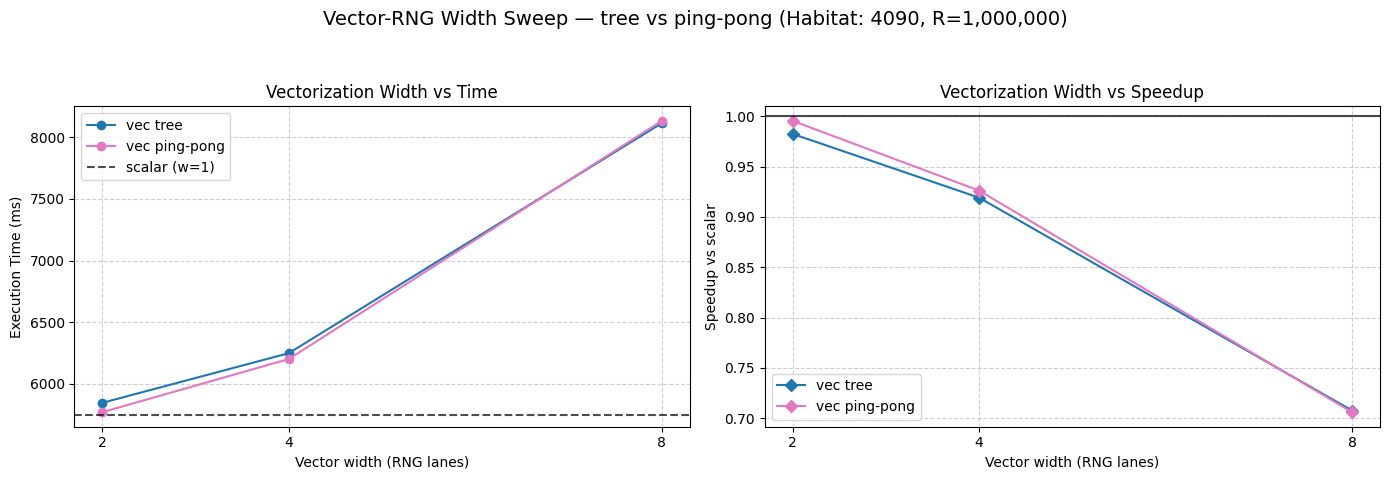

In [7]:
# Reuses target_habitat, MC_RUNS, THRESHOLD, SEED, N_BATCHES,
# n_wg_target and _canonical_topology defined in the Phase 1 cell.
# Compares the two vectorized reductions (tree vs ping-pong) across widths
# against the scalar baseline (w=1).
sweep_widths = [2, 4, 8]
vec_variants = {
    "vec tree":      PyOpenCLMonteCarloVectorizedAdapter,
    "vec ping-pong": PyOpenCLMonteCarloVectorizedPingPongAdapter,
}

def _time_ms(adapter):
    cfg = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED,
                           topology=_canonical_topology(adapter, n_wg_target))
    adapter.reset_profile()
    adapter.run(target_habitat, cfg)
    return adapter.benchmark()[0].mean_ms * N_BATCHES

base_t = _time_ms(PyOpenCLMonteCarloAdapter(profiling=True))  # scalar baseline (w=1)
sweep_rows = [{"Variant": "scalar", "Width": 1, "Time (ms)": base_t, "Speedup": 1.0}]
for name, cls in vec_variants.items():
    for w in sweep_widths:
        t = _time_ms(cls(profiling=True, vec_width=w))
        sweep_rows.append({"Variant": name, "Width": w, "Time (ms)": t,
                           "Speedup": base_t / t})

df_sweep = pd.DataFrame(sweep_rows)
display(df_sweep.style.format({"Time (ms)": "{:.2f}", "Speedup": "{:.2f}x"}))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))
for name, color in [("vec tree", "#1f77b4"), ("vec ping-pong", "#e377c2")]:
    sub = df_sweep[df_sweep["Variant"] == name]
    axA.plot(sub["Width"], sub["Time (ms)"], marker="o", label=name, color=color)
    axB.plot(sub["Width"], sub["Speedup"], marker="D", label=name, color=color)
axA.axhline(base_t, color="black", linestyle="--", alpha=0.7, label="scalar (w=1)")
axA.set_xlabel("Vector width (RNG lanes)"); axA.set_ylabel("Execution Time (ms)")
axA.set_title("Vectorization Width vs Time"); axA.set_xticks(sweep_widths)
axA.grid(True, linestyle="--", alpha=0.6); axA.legend()
axB.axhline(1.0, color="black", linestyle="-", alpha=0.7)
axB.set_xlabel("Vector width (RNG lanes)"); axB.set_ylabel("Speedup vs scalar")
axB.set_title("Vectorization Width vs Speedup"); axB.set_xticks(sweep_widths)
axB.grid(True, linestyle="--", alpha=0.6); axB.legend()
plt.suptitle(f"Vector-RNG Width Sweep — tree vs ping-pong (Habitat: {target_habitat.habitat_code}, R={MC_RUNS:,})", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.93]); plt.show()

## Phase 3: Decoupled LWS and GWS Parameter Tuning Analysis

Following our optimizations to parameterize work-group sizes dynamically, the GPU parameter tuning sweep was executed using the standalone Python script `benchmark/benchmark_lws_gws.py`. The execution, profiling, and hardware telemetry have been decoupled from this notebook. The results were exported into the structured data file `benchmark/lws_gws_benchmark.csv`.

We now load the benchmark CSV data and plot the **Computational Throughput** and **Relative Performance (Deviation from Group Mean %)** to analyze work-group scaling behavior.

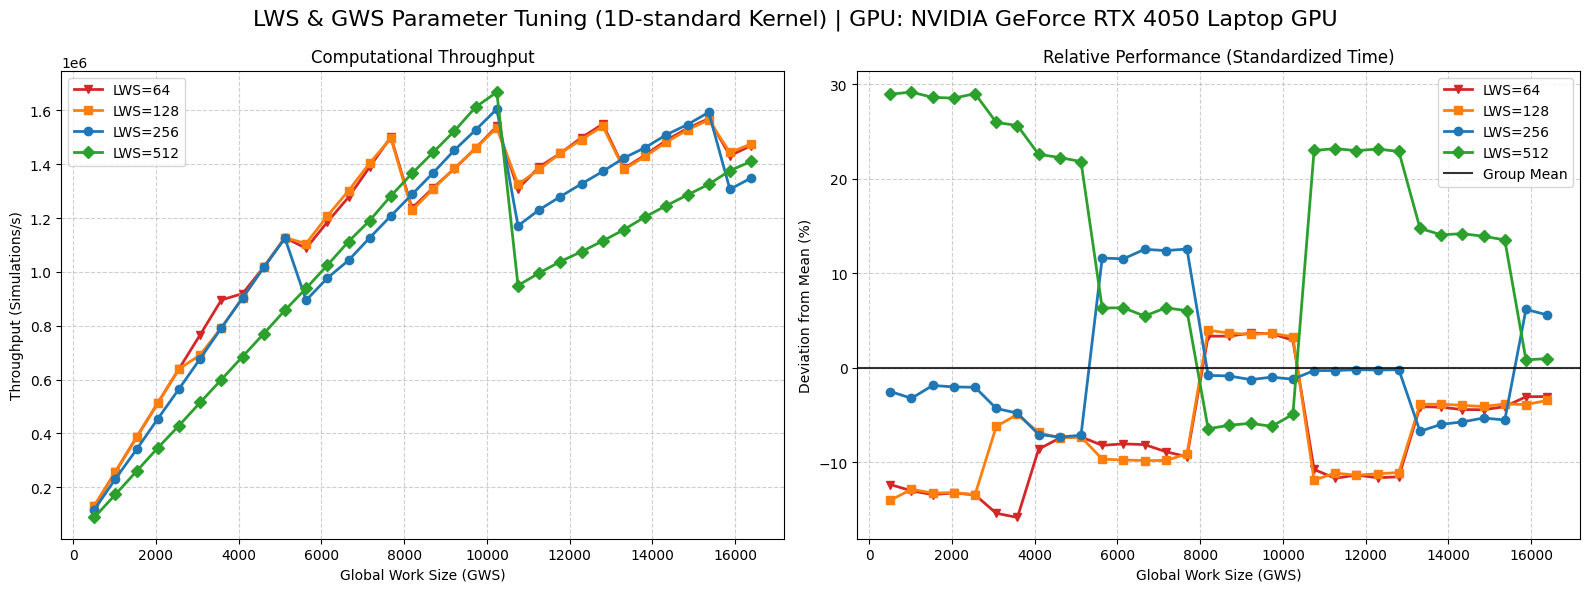

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the benchmark CSV generated by benchmark_lws_gws.py
csv_path = Path("lws_gws_benchmark.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Benchmark data not found at '{csv_path}'. Please run the python sweep script first!")

df_bench = pd.read_csv(csv_path)
gpu_name = df_bench["GPU"].iloc[0] if "GPU" in df_bench.columns else "Unknown GPU"
kernel_label = df_bench["Kernel"].iloc[0] if "Kernel" in df_bench.columns else "Standard"

lws_options = sorted(df_bench["LWS"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_lws = {
    64:  "#d62728",
    128: "#ff7f0e",
    256: "#1f77b4",
    512: "#2ca02c"
}
markers_lws = {
    64:  "v",
    128: "s",
    256: "o",
    512: "D"
}

for lws in lws_options:
    sub_df = df_bench[df_bench["LWS"] == lws].sort_values("GWS")
    
    # Plot Throughput
    ax1.plot(
        sub_df["GWS"],
        sub_df["Throughput (Sim/s)"],
        marker=markers_lws[lws],
        label=f"LWS={lws}",
        color=colors_lws[lws],
        linewidth=2
    )
    
    # Plot Standardized Relative Time (Deviation from Mean %)
    ax2.plot(
        sub_df["GWS"],
        sub_df["Deviation from Mean (%)"],
        marker=markers_lws[lws],
        label=f"LWS={lws}",
        color=colors_lws[lws],
        linewidth=2
    )

# Subplot 1: Throughput
ax1.set_xlabel("Global Work Size (GWS)")
ax1.set_ylabel("Throughput (Simulations/s)")
ax1.set_title("Computational Throughput")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Relative Performance
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Global Work Size (GWS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.suptitle(f"LWS & GWS Parameter Tuning ({kernel_label} Kernel) | GPU: {gpu_name}", fontsize=16)
plt.tight_layout()
plt.show()

## Statistical Robustness: Scalar vs. Vectorized Kernels

The plot below visualises the **two-proportion Z-test** for each vectorized
kernel against the scalar baseline.

- The **grey curve** is the $\mathcal{N}(0,1)$ null distribution.
- The **red shaded regions** are the rejection zones $|z| > z_{\alpha/2}$.
- The **dashed red lines** mark $\pm z_{\alpha/2}$ (critical values).
- Each **solid coloured vertical line** is the observed $z$-statistic for one kernel.
- The **translucent shaded area** beyond each observed $z$ toward the tail
  represents the contribution to the $p$-value (two-tailed).

Data are loaded from `benchmark/statistical_robustness.csv`
(generated by `benchmark/statistical_robustness.py`).

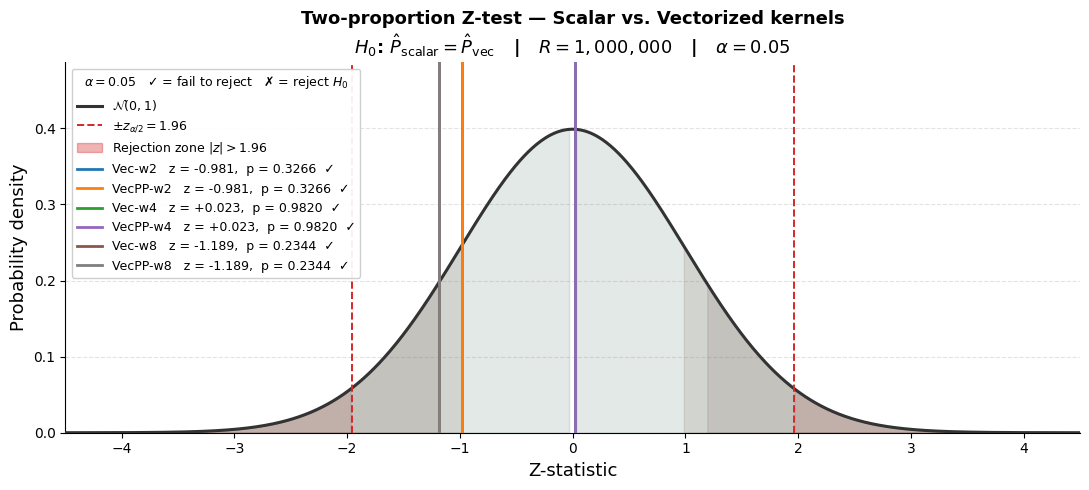

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import norm

# ── Load data ──────────────────────────────────────────────────────────────
csv_path = Path("statistical_robustness.csv")
if not csv_path.exists():
    raise FileNotFoundError(
        f"'{csv_path}' not found. Run:\n"
        "  python benchmark/statistical_robustness.py"
    )

df = pd.read_csv(csv_path)
ALPHA  = float(df["alpha"].iloc[0])
R      = int(df["R"].iloc[0])
z_crit = norm.ppf(1 - ALPHA / 2)   # 1.96 for α = 0.05

# Kernel display order & colour palette
KERNEL_ORDER = ["Vec-w2", "VecPP-w2", "Vec-w4", "VecPP-w4", "Vec-w8", "VecPP-w8"]
KERNEL_ORDER = [k for k in KERNEL_ORDER if k in df["kernel_vec"].values]
palette   = plt.cm.tab10(np.linspace(0, 0.7, len(KERNEL_ORDER)))
color_map = dict(zip(KERNEL_ORDER, palette))

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# N(0,1) curve
x = np.linspace(-4.5, 4.5, 1_000)
ax.plot(x, norm.pdf(x), color="#333333", lw=2.2, zorder=3,
        label=r"$\mathcal{N}(0,1)$")

# Red rejection regions
for x_rej in [x[x >= z_crit], x[x <= -z_crit]]:
    ax.fill_between(x_rej, norm.pdf(x_rej),
                    alpha=0.15, color="#d62728", zorder=1)

# Dashed critical-value lines
ax.axvline( z_crit, color="#d62728", lw=1.4, linestyle="--", zorder=4,
            label=f"$\\pm z_{{\\alpha/2}} = {z_crit:.2f}$")
ax.axvline(-z_crit, color="#d62728", lw=1.4, linestyle="--", zorder=4)

# One vertical line per kernel + tail shading for the p-value area
for kernel in KERNEL_ORDER:
    row      = df[df["kernel_vec"] == kernel].iloc[0]
    z_obs    = float(row["z_stat"])
    p_val    = float(row["p_value_ztest"])
    rejected = bool(row["reject_H0_ztest"])

    if np.isnan(z_obs):
        continue

    col   = color_map[kernel]
    label = (f"{kernel}   z = {z_obs:+.3f},  p = {p_val:.4f}"
             + ("  ✗" if rejected else "  ✓"))

    # Solid vertical line at the observed statistic
    ax.axvline(z_obs, color=col, lw=2.0, linestyle="-", zorder=5, label=label)

    # Translucent tail shading (both sides) = p-value area
    abs_z = abs(z_obs)
    for sign in [+1, -1]:
        x_tail = x[(sign * x) >= abs_z]
        if len(x_tail):
            ax.fill_between(x_tail, norm.pdf(x_tail),
                            color=col, alpha=0.09, zorder=2)

# ── Formatting ─────────────────────────────────────────────────────────────
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(0, norm.pdf(0) * 1.22)
ax.set_xlabel("Z-statistic", fontsize=13)
ax.set_ylabel("Probability density", fontsize=13)
ax.set_title(
    "Two-proportion Z-test — Scalar vs. Vectorized kernels\n"
    rf"$H_0$: $\hat{{P}}_{{\mathrm{{scalar}}}} = \hat{{P}}_{{\mathrm{{vec}}}}$"
    f"   |   $R = {R:,}$   |   $\\alpha = {ALPHA}$",
    fontsize=13, fontweight="bold",
)

# Rejection patch for legend
rej_patch = mpatches.Patch(color="#d62728", alpha=0.35,
                           label=f"Rejection zone $|z| > {z_crit:.2f}$")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=[handles[0], handles[1], rej_patch] + handles[2:],
    labels =[labels[0],  labels[1],  rej_patch.get_label()] + labels[2:],
    fontsize=9, loc="upper left",
    framealpha=0.93, edgecolor="#cccccc",
    title=f"$\\alpha = {ALPHA}$   ✓ = fail to reject   ✗ = reject $H_0$",
    title_fontsize=9,
)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 4: All-Habitats Time — Habitat-Centric vs Map-Centric

The plots above are for a single habitat. Here we compare the **total execution time across all habitats** (the full pipeline workload) and add the new **Map-Centric** bitmask kernel.

- **Habitat-Centric** (Standard / Ping-Pong 1-D): one kernel launch per habitat; total time is the sum over all habitats.
- **Map-Centric**: a single batched sweep (`run_map`) that processes all habitats at once — one RNG draw per map cell updates every habitat present in that cell via a 64-bit bitmask. It runs over the **union footprint** of the habitats (the efficient form; sweeping the full 5.24 M-cell grid of mostly-empty cells would be pointless).

> **Important — in this dataset the habitats do *not* overlap.** The 5 real habitats are spatially disjoint (sum of cells = union footprint = 720,595 → **overlap 1.00×**). The Map-Centric advantage comes *only* from reusing one RNG draw across overlapping habitats, so with zero overlap it issues exactly as many draws as Habitat-Centric while adding the per-cell inner loop over habitats and the 64-wide private accumulators — hence it is **expected to be slower here** (~2.4× at R = 1 M). The destruction probabilities match the baseline, confirming correctness; the paradigm only pays off on heavily-overlapping habitat sets.

Two figures, each reproducing the **top row** of the analysis above (absolute time + standardized *deviation from mean*): one **vs Ping-Pong 1-D**, one **vs the Map-Centric kernel**.

In [10]:
# ── Phase 4: all-habitats time — Habitat-Centric vs Map-Centric ──
import time

from pyroclast import InvasionCriteria, PyOpenCLMapCentricAdapter, SpatialHabitat

# The compacted habitats no longer carry spatial layout, so we rebuild the
# Map-Centric inputs from the *raw, co-registered* rasters. Map-Centric runs
# over the union footprint of all habitats (sweeping the full mostly-empty
# 5.24M-cell grid would be pointless), expressed as a single (1, L) row.
invasion = repo.get(InvasionCriteria())
p_full = invasion.data.astype(np.float32)
risk = p_full > 0.0

masks = {}
union = np.zeros(p_full.shape, dtype=bool)
for h in repo.matching(HabitatCriteria()):
    m = (h.data > 0) & risk          # habitat ∩ footprint == the compaction cells
    masks[h.code] = m
    union |= m
union_idx = np.flatnonzero(union.ravel())

p_union = np.ascontiguousarray(
    p_full.ravel()[union_idx], dtype=np.float32
).reshape(1, -1)
spatial_habitats = [
    SpatialHabitat(code, masks[code].ravel()[union_idx].reshape(1, -1), THRESHOLD)
    for code in sorted(masks)
]

sum_cells = sum(int(m.sum()) for m in masks.values())
print(
    f"All habitats: {len(spatial_habitats)} | grid = {p_full.shape} "
    f"({p_full.size:,} cells) | union footprint = {union_idx.size:,} cells | "
    f"overlap = {sum_cells / max(1, union_idx.size):.2f}x"
)

# Adapters built once (avoid per-point recompilation).
mc_standard = PyOpenCLMonteCarloAdapter()
mc_pingpong = PyOpenCLMonteCarloPingPongAdapter()
mc_mapcentric = PyOpenCLMapCentricAdapter()


def _time_habitat_centric(adapter, runs):
    """Wall-clock (ms) for the iterative loop over ALL compacted habitats."""
    adapter._queue.finish()
    t0 = time.perf_counter()
    for h in compacted:
        cfg = MonteCarloConfig(
            n_runs=runs, threshold=THRESHOLD, seed=SEED,
            topology=_canonical_topology(adapter, n_wg_target),
        )
        adapter.run(h, cfg)
    adapter._queue.finish()
    return (time.perf_counter() - t0) * 1e3


def _time_map_centric(adapter, runs):
    """Wall-clock (ms) for one batched run_map over all habitats."""
    cfg = MonteCarloConfig(n_runs=runs, threshold=THRESHOLD, seed=SEED)
    adapter._queue.finish()
    t0 = time.perf_counter()
    adapter.run_map(p_union, spatial_habitats, cfg)
    adapter._queue.finish()
    return (time.perf_counter() - t0) * 1e3


P4_RUNS = list(range(1_000_000, 2_000_000 + 1, 100_000))
p4_series = {"Standard": [], "Ping-Pong": [], "Map-Centric": []}

print("Running Phase 4 all-habitats time sweep...")
for runs in P4_RUNS:
    p4_series["Standard"].append(_time_habitat_centric(mc_standard, runs))
    p4_series["Ping-Pong"].append(_time_habitat_centric(mc_pingpong, runs))
    p4_series["Map-Centric"].append(_time_map_centric(mc_mapcentric, runs))
    print(f"  Completed R={runs:,}", end="\r")
print("\nPhase 4 sweep completed.")

All habitats: 5 | grid = (2423, 2164) (5,243,372 cells) | union footprint = 720,595 cells | overlap = 1.00x
Running Phase 4 all-habitats time sweep...
  Completed R=2,000,000
Phase 4 sweep completed.


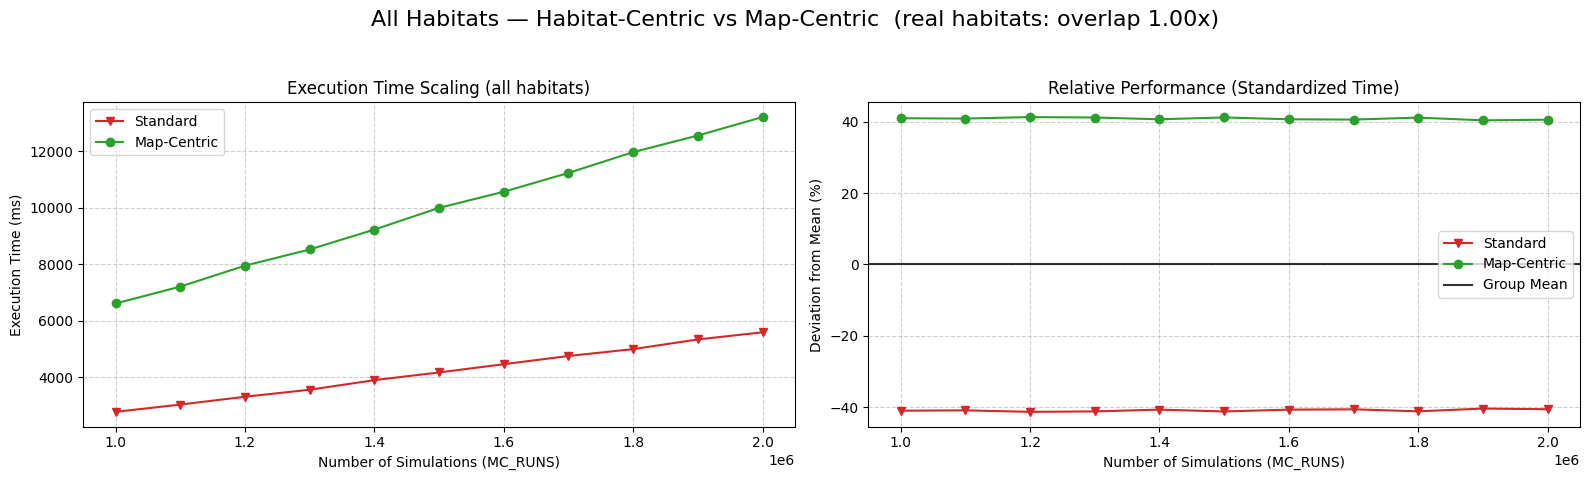

In [11]:
# ── Phase 4 plots: two top-row comparisons (absolute + standardized time) ──
P4_COLORS = {"Standard": "#d62728", "Ping-Pong": "#ff7f0e", "Map-Centric": "#2ca02c"}
P4_MARKERS = {"Standard": "v", "Ping-Pong": "s", "Map-Centric": "o"}


def _plot_time_pair(names, suptitle):
    """Replicate the top row of the analysis (absolute + standardized time)."""
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5))

    # Left: absolute execution time scaling
    for n in names:
        axL.plot(P4_RUNS, p4_series[n], marker=P4_MARKERS[n],
                 color=P4_COLORS[n], label=n)
    axL.set_xlabel("Number of Simulations (MC_RUNS)")
    axL.set_ylabel("Execution Time (ms)")
    axL.set_title("Execution Time Scaling (all habitats)")
    axL.grid(True, linestyle="--", alpha=0.6)
    axL.legend()

    # Right: standardized relative time (deviation from the group mean, %)
    for n in names:
        dev = []
        for i in range(len(P4_RUNS)):
            group_mean = np.mean([p4_series[m][i] for m in names])
            dev.append((p4_series[n][i] / group_mean - 1.0) * 100.0)
        axR.plot(P4_RUNS, dev, marker=P4_MARKERS[n],
                 color=P4_COLORS[n], label=n)
    axR.axhline(0.0, color="black", linestyle="-", alpha=0.8, label="Group Mean")
    axR.set_xlabel("Number of Simulations (MC_RUNS)")
    axR.set_ylabel("Deviation from Mean (%)")
    axR.set_title("Relative Performance (Standardized Time)")
    axR.grid(True, linestyle="--", alpha=0.6)
    axR.legend()

    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    plt.show()

# Figure — vs the new Map-Centric kernel (all habitats)
_plot_time_pair(
    ["Standard", "Map-Centric"],
    "All Habitats — Habitat-Centric vs Map-Centric  (real habitats: overlap 1.00x)",
)